# Phase 3 — ML Feature Engineering

This notebook validates the causal, regime-relevant features built for the ETF-only
and full nine-asset universes (`src/ml_features.py`).

**Where these features go.** They are not consumed here. The Phase 4 regime models
(HMM, dynamic covariance) receive them through the Phase 2 backtest engine's `extras`
channel, which slices every frame to `:τ` before each rebalance fit. So the same
no-lookahead guarantee that governs returns also governs these features — proven
end-to-end in `tests/test_phase3_integration.py`, where corrupting a feature frame's
future cannot change any past weight.

**Two causality conventions, on purpose.** Return features at date *t* use observations
up to and including *t* (known at the close) and are deliberately **not** lagged — the
engine's fit-at-τ / earn-from-τ+1 timing makes them causal. Macro signals **are** lagged
by at least one day, because a release dated *t* may not be knowable intraday. Scaling is
**not** applied globally; each Phase 4 model fits its scaler only inside its own training
window (recorded in the manifest as `global_standardization: false`).


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Support execution either from the repository root or from notebooks/.
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "The project data directory could not be found. "
        "Run this notebook from the Portfolio_ML repository."
    )

print(f"Project root: {ROOT}")

Project root: /Users/apple/Projects/Portfolio_ML


In [2]:
ETF_FEATURES_PATH = ROOT / "data/gold/ml_features_etf.parquet"
FULL_FEATURES_PATH = ROOT / "data/gold/ml_features_full.parquet"
MANIFEST_PATH = ROOT / "data/gold/ml_features_manifest.json"

for path in [
    ETF_FEATURES_PATH,
    FULL_FEATURES_PATH,
    MANIFEST_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 3 artifact: {path}")

etf_features = pd.read_parquet(ETF_FEATURES_PATH)
full_features = pd.read_parquet(FULL_FEATURES_PATH)

with MANIFEST_PATH.open(encoding="utf-8") as file:
    manifest = json.load(file)

print("ETF features:", etf_features.shape)
print("Full-universe features:", full_features.shape)

ETF features: (2422, 13)
Full-universe features: (1250, 13)


## 1. Feature-set validation

The Phase 3 pipeline produces market, risk, dependence and macroeconomic
features. All rolling calculations use current and past observations only.

In [3]:
core_features = [
    "MARKET_RETURN",
    "MARKET_VOL_SHORT",
    "MARKET_VOL_LONG",
    "AVG_PAIRWISE_CORR",
    "CROSS_SECTIONAL_DISPERSION",
    "MARKET_DRAWDOWN",
]

missing_etf = [
    column
    for column in core_features
    if column not in etf_features.columns
]

missing_full = [
    column
    for column in core_features
    if column not in full_features.columns
]

assert not missing_etf, f"Missing ETF features: {missing_etf}"
assert not missing_full, f"Missing full-universe features: {missing_full}"

print("Core feature validation passed.")
print("\nETF columns:")
print(etf_features.columns.tolist())

print("\nFull-universe columns:")
print(full_features.columns.tolist())

Core feature validation passed.

ETF columns:
['MARKET_RETURN', 'MARKET_VOL_SHORT', 'MARKET_VOL_LONG', 'AVG_PAIRWISE_CORR', 'CROSS_SECTIONAL_DISPERSION', 'MARKET_DRAWDOWN', 'VIX_DIFF_L1', 'US10Y_DIFF_L1', 'DXY_DIFF_L1', 'CREDIT_SPREAD_DIFF_L1', 'EURMAD_DIFF_L1', 'USDMAD_DIFF_L1', 'TAUX_DIR_DIFF_L1']

Full-universe columns:
['MARKET_RETURN', 'MARKET_VOL_SHORT', 'MARKET_VOL_LONG', 'AVG_PAIRWISE_CORR', 'CROSS_SECTIONAL_DISPERSION', 'MARKET_DRAWDOWN', 'VIX_DIFF_L1', 'US10Y_DIFF_L1', 'DXY_DIFF_L1', 'CREDIT_SPREAD_DIFF_L1', 'EURMAD_DIFF_L1', 'USDMAD_DIFF_L1', 'TAUX_DIR_DIFF_L1']


## 2. Temporal coverage

In [4]:
coverage = pd.DataFrame(
    {
        "Universe": ["ETF 2017+", "Full 2021+"],
        "Rows": [
            len(etf_features),
            len(full_features),
        ],
        "Columns": [
            etf_features.shape[1],
            full_features.shape[1],
        ],
        "Start": [
            etf_features.index.min(),
            full_features.index.min(),
        ],
        "End": [
            etf_features.index.max(),
            full_features.index.max(),
        ],
    }
)

coverage

,Universe,Rows,Columns,Start,End
0,ETF 2017+,2422,13,2017-03-31,2026-07-13
1,Full 2021+,1250,13,2021-09-28,2026-07-13


## 3. Descriptive statistics

In [5]:
etf_features[core_features].describe().T

,count,mean,std,min,25%,50%,75%,max
MARKET_RETURN,2422.0,0.000394,0.007988,-0.067349,-0.003243,0.000645,0.004382,0.064486
MARKET_VOL_SHORT,2422.0,0.111999,0.059494,0.036687,0.074955,0.098769,0.134242,0.547145
MARKET_VOL_LONG,2422.0,0.114650,0.051075,0.047330,0.081674,0.104629,0.134029,0.341837
AVG_PAIRWISE_CORR,2422.0,0.271163,0.131741,-0.009309,0.172775,0.257774,0.362565,0.672837
CROSS_SECTIONAL_DISPERSION,2422.0,0.007693,0.005899,0.000000,0.004105,0.006432,0.009674,0.087111
MARKET_DRAWDOWN,2422.0,-0.050056,0.061571,-0.269957,-0.068324,-0.023938,-0.004729,0.000000


In [6]:
full_features[core_features].describe().T

,count,mean,std,min,25%,50%,75%,max
MARKET_RETURN,1250.0,0.000174,0.006305,-0.036162,-0.003067,0.000460,0.003620,0.030319
MARKET_VOL_SHORT,1250.0,0.094404,0.032452,0.034716,0.071883,0.086533,0.111514,0.208498
MARKET_VOL_LONG,1250.0,0.095502,0.024946,0.059478,0.074989,0.091520,0.110322,0.164719
AVG_PAIRWISE_CORR,1250.0,0.155216,0.057969,0.004991,0.120669,0.148595,0.183196,0.358124
CROSS_SECTIONAL_DISPERSION,1250.0,0.010285,0.005636,0.000000,0.006505,0.009192,0.012528,0.057002
MARKET_DRAWDOWN,1250.0,-0.070540,0.068404,-0.242561,-0.121702,-0.040506,-0.013719,0.000000


## 4. Short- and long-term market volatility

Short-term volatility reacts quickly to recent shocks, while long-term
volatility describes a more persistent level of market risk.

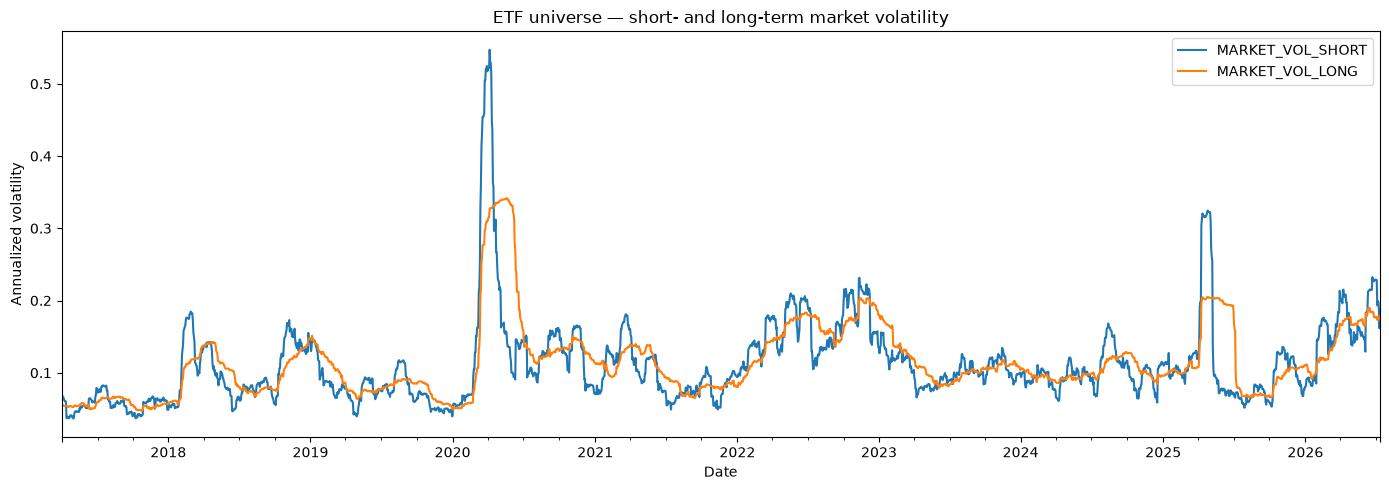

In [7]:
ax = etf_features[
    ["MARKET_VOL_SHORT", "MARKET_VOL_LONG"]
].plot(
    figsize=(14, 5),
    title="ETF universe — short- and long-term market volatility",
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
plt.tight_layout()
plt.show()

## 5. Average pairwise correlation

An increase in average cross-asset correlation indicates that diversification
may become less effective, especially during periods of market stress.

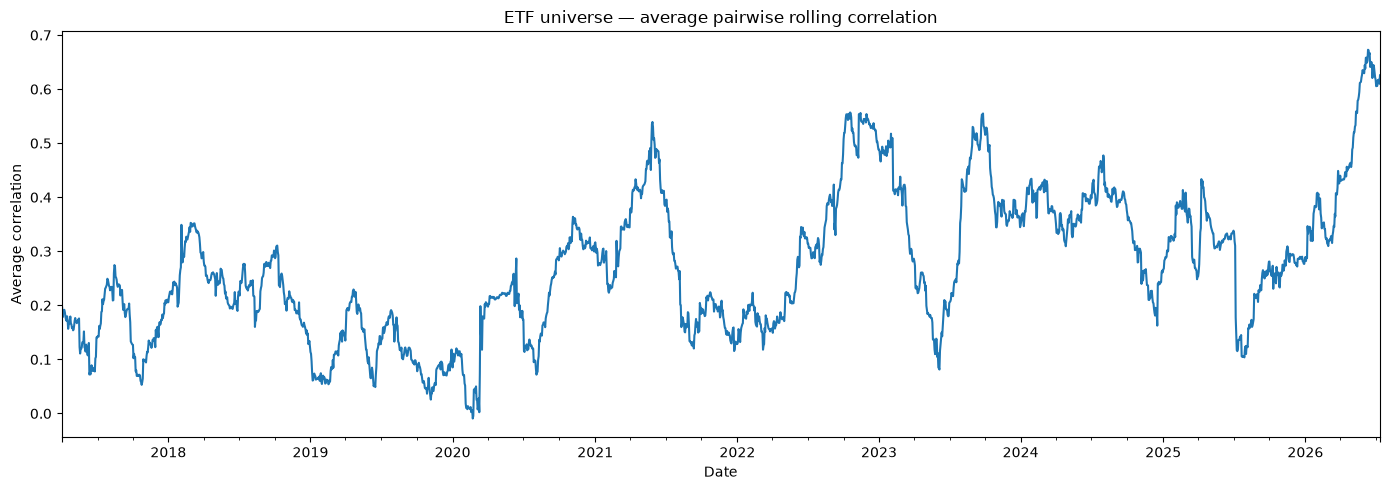

In [8]:
ax = etf_features["AVG_PAIRWISE_CORR"].plot(
    figsize=(14, 5),
    title="ETF universe — average pairwise rolling correlation",
)

ax.set_xlabel("Date")
ax.set_ylabel("Average correlation")
plt.tight_layout()
plt.show()

## 6. Cross-sectional dispersion

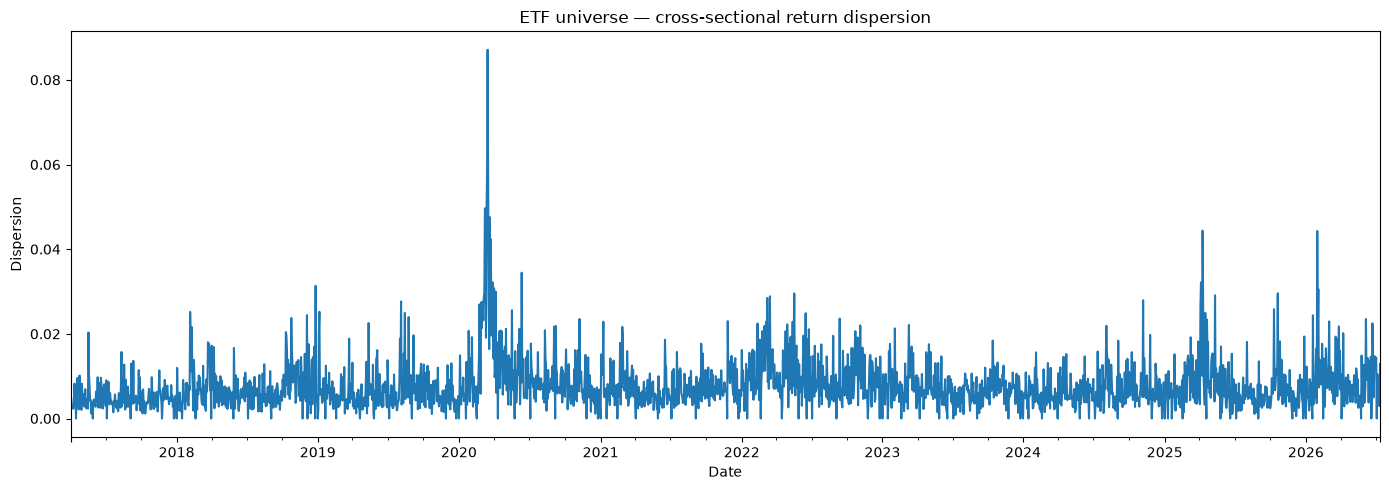

In [9]:
ax = etf_features["CROSS_SECTIONAL_DISPERSION"].plot(
    figsize=(14, 5),
    title="ETF universe — cross-sectional return dispersion",
)

ax.set_xlabel("Date")
ax.set_ylabel("Dispersion")
plt.tight_layout()
plt.show()

## 7. Market drawdown

Drawdown measures the decline of the equal-weight market portfolio from its
previous historical peak.

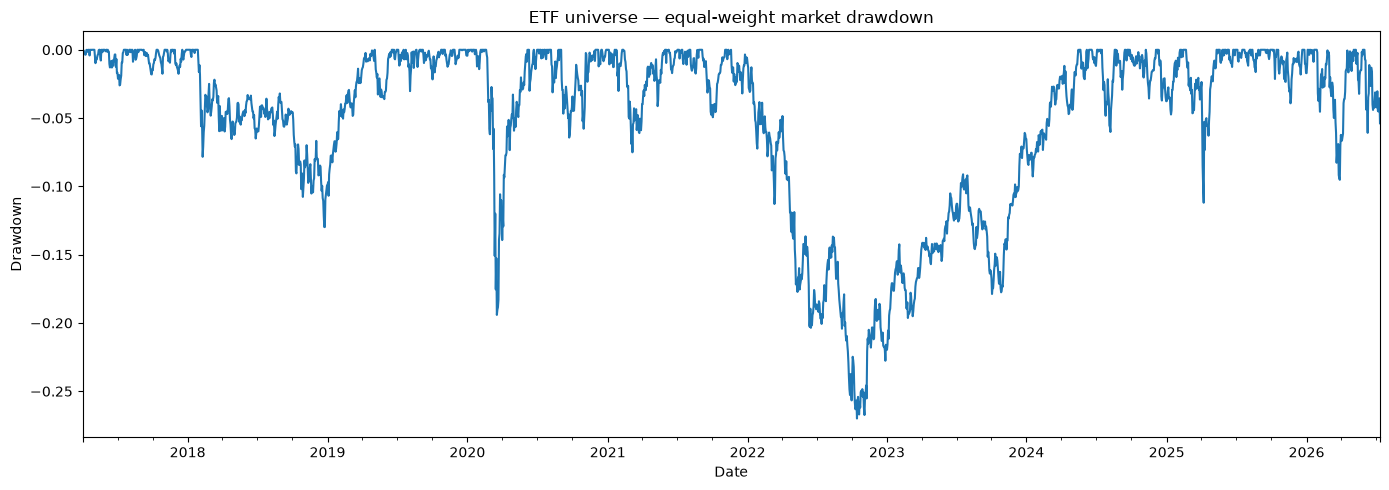

In [10]:
ax = etf_features["MARKET_DRAWDOWN"].plot(
    figsize=(14, 5),
    title="ETF universe — equal-weight market drawdown",
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
plt.tight_layout()
plt.show()

## 8. COVID-19 market shock

The ETF universe contains the 2020 COVID-19 crisis. This period is used to
verify whether the engineered variables capture changes in volatility,
dependence and market losses.

In [11]:
covid_features = etf_features.loc[
    "2020-02-01":"2020-06-30",
    [
        "MARKET_VOL_SHORT",
        "AVG_PAIRWISE_CORR",
        "MARKET_DRAWDOWN",
    ],
]

covid_features

,MARKET_VOL_SHORT,AVG_PAIRWISE_CORR,MARKET_DRAWDOWN
Date,,,
2020-02-03,0.063214,0.051673,-0.009016
2020-02-04,0.067211,0.018279,-0.001734
2020-02-05,0.067098,0.010229,0.000000
2020-02-06,0.068290,0.010734,0.000000
2020-02-07,0.068092,0.007934,-0.001715
...,...,...,...
2020-06-24,0.141091,0.186763,-0.010508
2020-06-25,0.141270,0.188781,-0.005224
2020-06-26,0.145707,0.177356,-0.014143


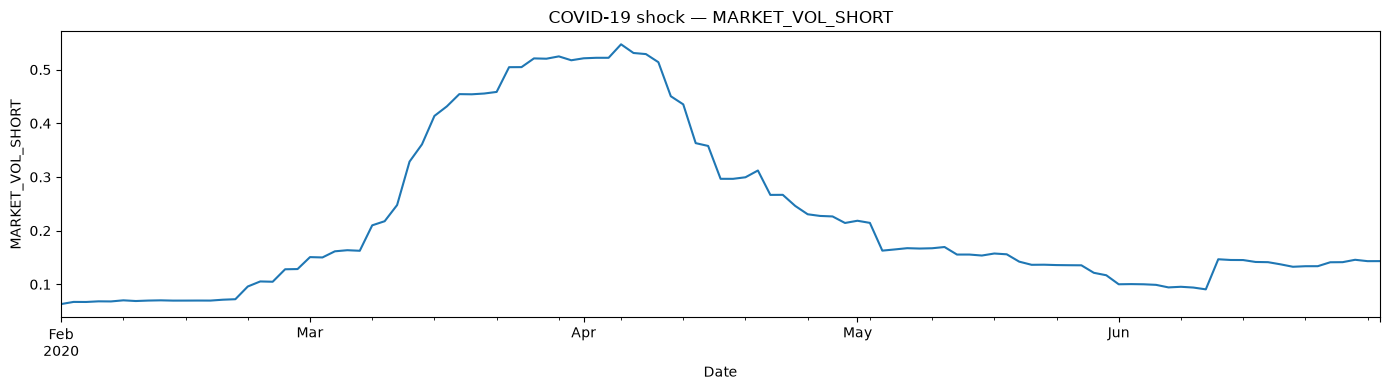

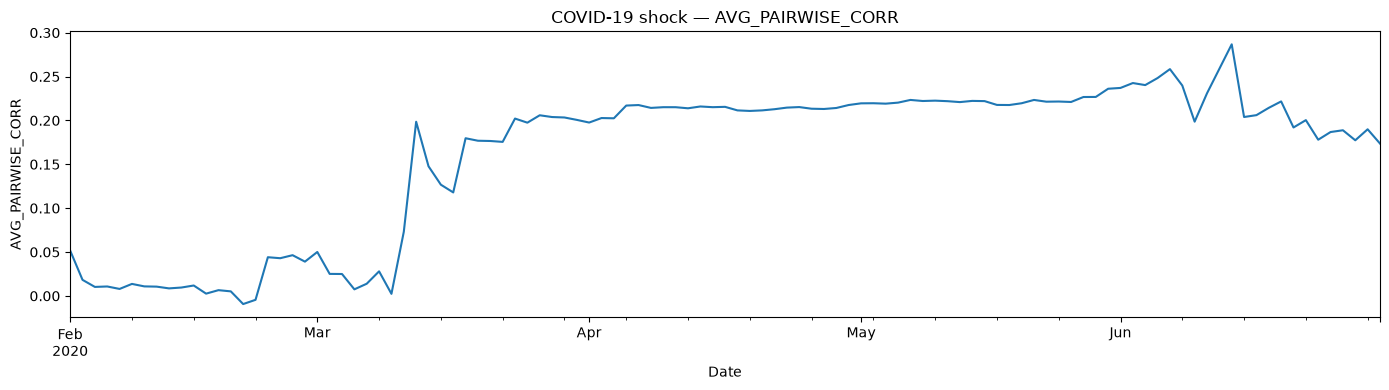

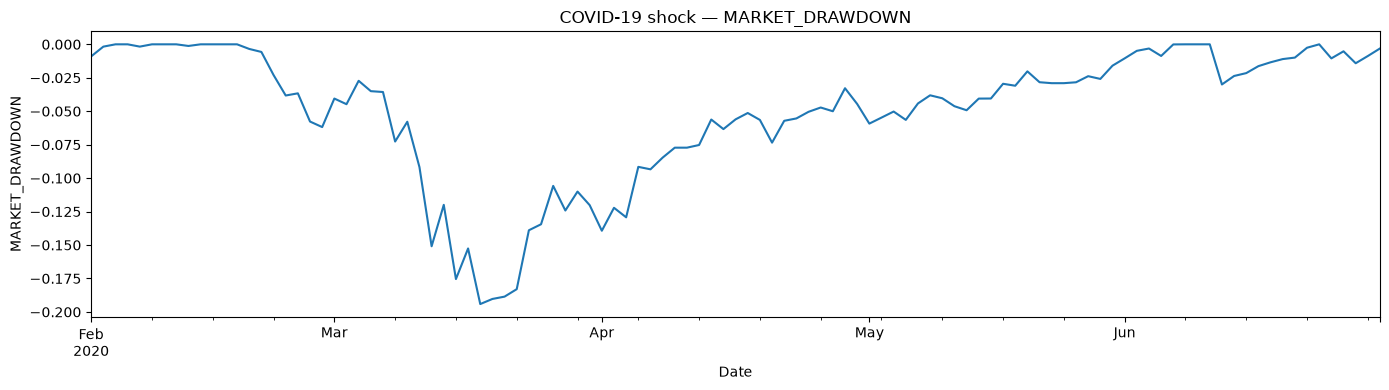

In [12]:
for column in covid_features.columns:
    ax = covid_features[column].plot(
        figsize=(14, 4),
        title=f"COVID-19 shock — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 9. 2022 rate shock

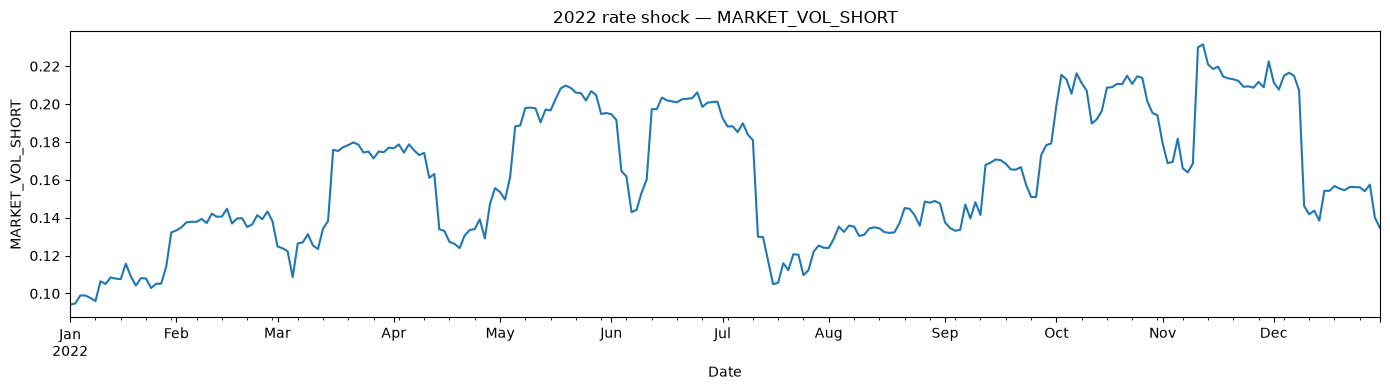

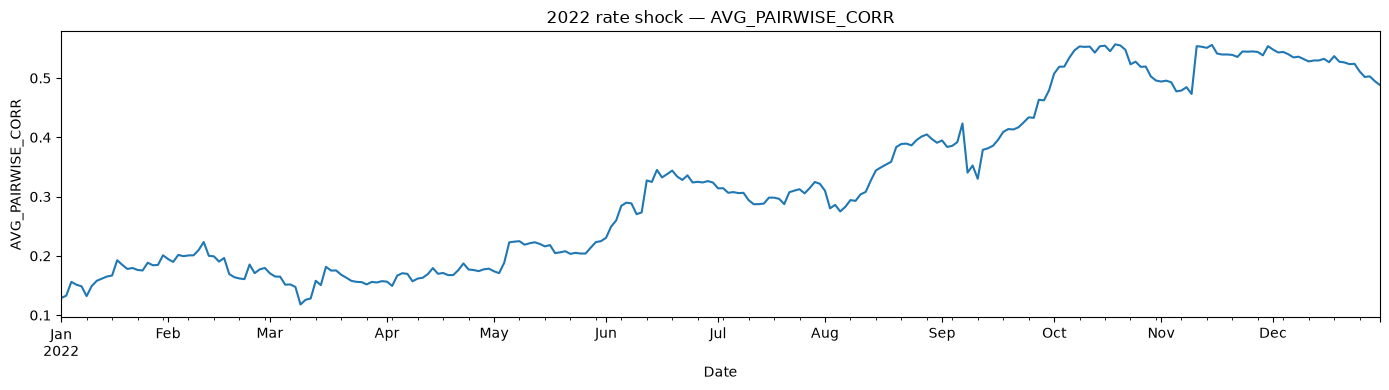

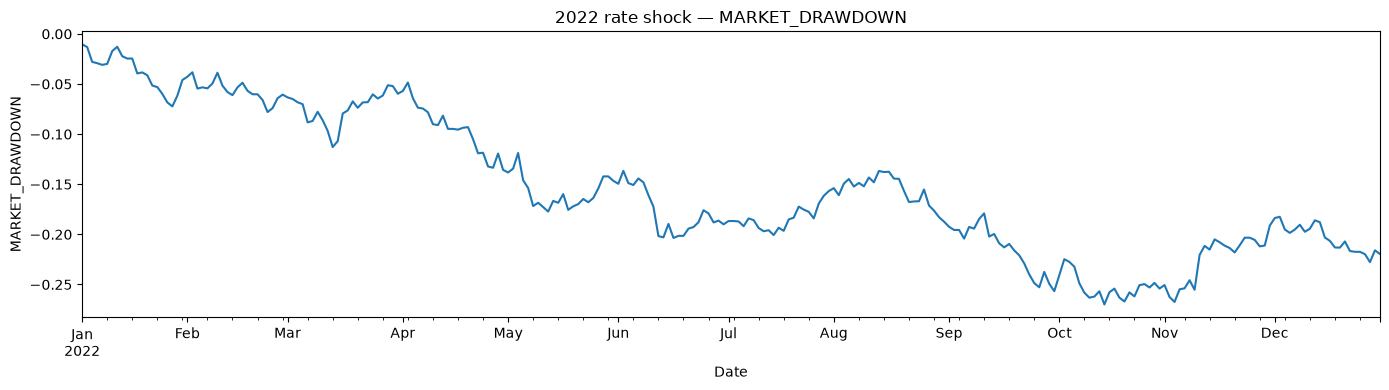

In [13]:
rate_shock_features = etf_features.loc[
    "2022-01-01":"2022-12-31",
    [
        "MARKET_VOL_SHORT",
        "AVG_PAIRWISE_CORR",
        "MARKET_DRAWDOWN",
    ],
]

for column in rate_shock_features.columns:
    ax = rate_shock_features[column].plot(
        figsize=(14, 4),
        title=f"2022 rate shock — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 10. Lagged macroeconomic signals

Macroeconomic variables are differenced and lagged by at least one day.
They are deliberately not standardized over the complete dataset.
Standardization will be fitted only on each Phase 4 training window.

In [14]:
macro_columns = [
    column
    for column in etf_features.columns
    if column.endswith("_DIFF_L1")
]

macro_columns

['VIX_DIFF_L1',
 'US10Y_DIFF_L1',
 'DXY_DIFF_L1',
 'CREDIT_SPREAD_DIFF_L1',
 'EURMAD_DIFF_L1',
 'USDMAD_DIFF_L1',
 'TAUX_DIR_DIFF_L1']

In [15]:
if macro_columns:
    etf_features[macro_columns].describe().T
else:
    print("No lagged macro columns were found.")

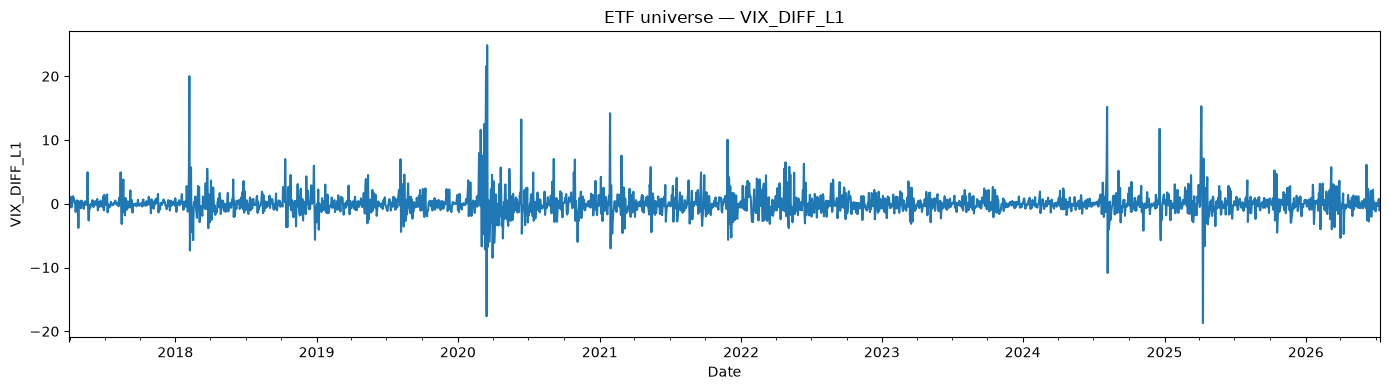

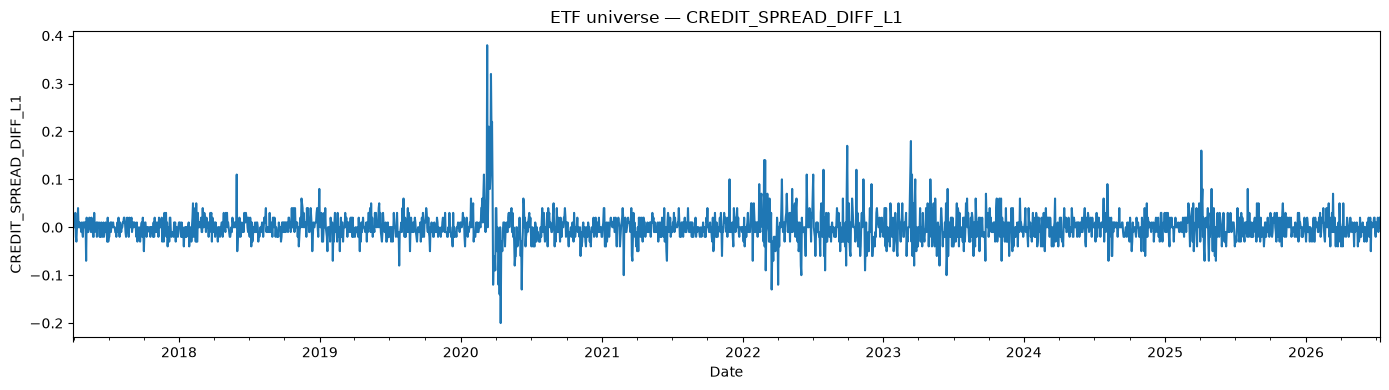

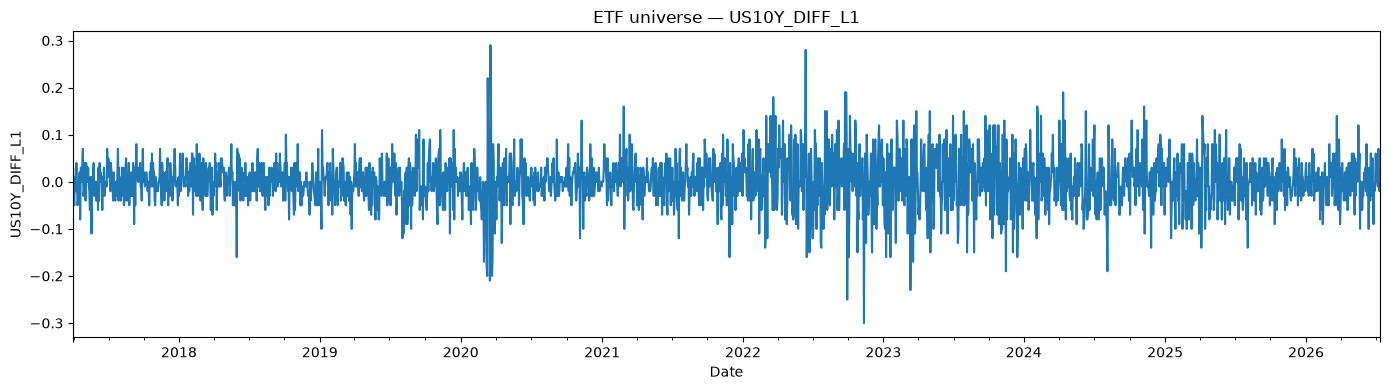

In [16]:
preferred_macro_columns = [
    column
    for column in [
        "VIX_DIFF_L1",
        "CREDIT_SPREAD_DIFF_L1",
        "US10Y_DIFF_L1",
    ]
    if column in etf_features.columns
]

for column in preferred_macro_columns:
    ax = etf_features[column].plot(
        figsize=(14, 4),
        title=f"ETF universe — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 11. Data-quality checks

Both feature matrices are **fully dense** — zero NaN. This is not automatic: the
FRED and Bank Al-Maghrib macro series publish on different calendars, so their
union carries interior gaps on dates only one source printed. Those gaps are
forward-filled (last known level carried forward — causal, never backward), so no
NaN is scattered through the differenced macro signals. Any genuinely late-starting
series would instead leave a *leading* warm-up, reported per universe in the
manifest as `max_leading_nan` (see below) — the count Phase 4's `min_train_days`
must exceed so the first fit sees a complete feature vector.


In [17]:
missing_values = pd.DataFrame(
    {
        "ETF_NaN": etf_features.isna().sum(),
        "Full_NaN": full_features.isna().sum(),
    }
).fillna(0).astype(int)

missing_values

,ETF_NaN,Full_NaN
MARKET_RETURN,0,0
MARKET_VOL_SHORT,0,0
MARKET_VOL_LONG,0,0
AVG_PAIRWISE_CORR,0,0
CROSS_SECTIONAL_DISPERSION,0,0
MARKET_DRAWDOWN,0,0
VIX_DIFF_L1,0,0
US10Y_DIFF_L1,0,0
DXY_DIFF_L1,0,0
CREDIT_SPREAD_DIFF_L1,0,0


In [18]:
quality_summary = pd.DataFrame(
    {
        "Universe": ["ETF 2017+", "Full 2021+"],
        "Infinite values": [
            int(
                np.isinf(
                    etf_features.select_dtypes(include="number")
                ).sum().sum()
            ),
            int(
                np.isinf(
                    full_features.select_dtypes(include="number")
                ).sum().sum()
            ),
        ],
        "Duplicated dates": [
            int(etf_features.index.duplicated().sum()),
            int(full_features.index.duplicated().sum()),
        ],
        "Sorted index": [
            etf_features.index.is_monotonic_increasing,
            full_features.index.is_monotonic_increasing,
        ],
    }
)

quality_summary

,Universe,Infinite values,Duplicated dates,Sorted index
0,ETF 2017+,0,0,True
1,Full 2021+,0,0,True


### Feature warm-up per universe

`max_leading_nan` is the longest leading-NaN run across feature columns — the warm-up a
Phase 4 backtest must clear. With the current windows it is comfortably below
`min_train_days = 252`, so the first rebalance already sees a dense feature vector.


In [19]:
warmup = pd.DataFrame(
    {
        "output_rows": {u: d["output_rows"] for u, d in manifest["universes"].items()},
        "max_leading_nan": {u: d["max_leading_nan"] for u, d in manifest["universes"].items()},
        "fully_complete_rows": {u: d["fully_complete_rows"] for u, d in manifest["universes"].items()},
    }
)
warmup

,output_rows,max_leading_nan,fully_complete_rows
etf_2017,2422,0,2422
full_2021,1250,0,1250


## 12. Reproducibility manifest

In [20]:
manifest

{'core_features': {'AVG_PAIRWISE_CORR': 'Mean off-diagonal trailing asset correlation.',
  'CROSS_SECTIONAL_DISPERSION': 'Same-day standard deviation across asset returns.',
  'MARKET_DRAWDOWN': 'Drawdown of cumulative equal-weight market wealth.',
  'MARKET_RETURN': 'Equal-weight cross-asset mean log-return.',
  'MARKET_VOL_LONG': 'Annualized longer trailing volatility of MARKET_RETURN.',
  'MARKET_VOL_SHORT': 'Annualized trailing volatility of MARKET_RETURN.'},
 'global_standardization': False,
 'parameters': {'correlation_min_periods': 42,
  'correlation_window': 63,
  'macro_lag_days': 1,
  'manifest_path': 'data/gold/ml_features_manifest.json',
  'volatility_long_window': 63,
  'volatility_short_window': 21},
 'pipeline': 'phase3_ml_features',
 'standardization_policy': 'Fit scaling only inside each Phase 4 strategy.fit training window.',
 'universes': {'etf_2017': {'columns': ['MARKET_RETURN',
    'MARKET_VOL_SHORT',
    'MARKET_VOL_LONG',
    'AVG_PAIRWISE_CORR',
    'CROSS_SECT

In [21]:
manifest_text = json.dumps(manifest).lower()

assert "global_standardization" in manifest_text
assert "false" in manifest_text

print("Manifest confirms that global standardization is disabled.")

Manifest confirms that global standardization is disabled.


## 13. Reaching Phase 4 — the feature seam

These matrices are handed to a Phase 4 strategy through the Phase 2 engine, unchanged:

```python
from backtest import run_backtest
features = pd.read_parquet('data/gold/ml_features_etf.parquet')
run_backtest(returns, MyRegimeStrategy(), extras={'features': features}, min_train_days=252)
```

The engine passes each strategy `extras['features'].loc[:τ]` at every rebalance τ, so a
model can read the latest regime signals but never a future row. `tests/test_phase3_integration.py` locks this in: a feature-driven probe strategy produces identical past
weights whether or not the feature frame's future is corrupted, while its post-cutoff
weights do move — proving the features are genuinely consumed and genuinely leak-free.


## Conclusions and limitations

- Phase 3 produced causal, regime-relevant features for the ETF-only (2017+) and
  full nine-asset (2021+) universes.
- Rolling return statistics use only current and past observations; macro signals
  are differenced and lagged by at least one day.
- Both feature matrices are fully dense (zero NaN) after forward-filling the
  multi-source macro calendar; any late-starting series' warm-up is reported as
  `max_leading_nan`.
- No global standardization is applied — each Phase 4 model fits its scaler inside
  its own walk-forward training window.
- Delivery to Phase 4 is through the Phase 2 engine's `extras` channel, carrying the
  same no-lookahead guarantee (proven in `tests/test_phase3_integration.py`).
- The ETF universe contains the COVID-19 crash and the 2022 rate shock; the full
  universe starts in 2021 because of the available BVC history.
- These variables *characterize* market conditions; no causal crisis-prediction
  claim is made at this stage — that is Phase 4's question.
